In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pandas as pd
from scipy import stats
import numpy as np
import config
import analysis_lib as alib

# Ensure figures render inline within the notebook
%matplotlib inline

In [2]:
def calculate_ensemble_significance(ensemble_data):
    """
    Performs a one-sample t-test on the ensemble at each grid cell against zero.
    Returns a spatial map of p-values.
    """
    print("  -> Calculating ensemble t-test significance...")
    try:
        model_dim_index = ensemble_data.dims.index('model')
    except ValueError:
        print("    ERROR: 'model' dimension not found.")
        return xr.full_like(ensemble_data.isel(model=0), np.nan)
        
    t_stat, p_val = stats.ttest_1samp(
        ensemble_data.values, 
        0, 
        axis=model_dim_index, 
        nan_policy='omit'
    )
    
    p_map = xr.DataArray(
        p_val,
        coords={k: v for k, v in ensemble_data.coords.items() if k != 'model'},
        dims=[d for d in ensemble_data.dims if d != 'model']
    )
    return p_map

def get_regional_mean(data_map, region_name='study'):
    """Calculates the spatial mean of a map within a named bounding box."""
    b = config.BOUNDS[region_name]
    region_data = data_map.sel(
        lat=slice(b['lat_min'], b['lat_max']), 
        lon=slice(b['lon_min'], b['lon_max'])
    )
    return region_data.mean().compute().item()

In [3]:
print("--- 1. Starting Data Loading ---")

fig_dir = config.OUTPUT_DIR / "figures"
csv_dir = config.OUTPUT_DIR / "csv_data"
fig_dir.mkdir(exist_ok=True, parents=True)
csv_dir.mkdir(exist_ok=True, parents=True)

obs, amip, cmip = {}, {}, {}
indices_to_load = config.INDICES_TO_PLOT
periods_to_process = list(config.ANALYSIS_PERIODS.keys())

print(f"Loading all .nc files for periods: {periods_to_process}")

for period in periods_to_process:
    print(f"  -> Loading data for: {period}")
    spatial_data = alib.load_ensemble_maps(period)
    
    obs[period] = spatial_data['obs']
    amip[period] = spatial_data['amip']
    cmip[period] = spatial_data['cmip']
        
print("✅ All data successfully loaded.")

--- 1. Starting Data Loading ---
Loading all .nc files for periods: ['MAM', 'March', 'April', 'May']
  -> Loading data for: MAM
    ... (Lib) Loading Ensemble Spatial Data for: MAM ...


    Loading 25 trend files for AMIP trend data <xarray.DataArray 'precip_trend' (model: 25, lat: 181, lon: 361)> Size: 7MB
dask.array<concatenate, shape=(25, 181, 361), dtype=float32, chunksize=(1, 181, 361), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB -180.0 -179.0 -178.0 -177.0 ... 178.0 179.0 180.0
Dimensions without coordinates: model
Attributes:
    units:    mm/month
    Loading 85 trend files for CMIP trend data <xarray.DataArray 'precip_trend' (model: 85, lat: 181, lon: 361)> Size: 22MB
dask.array<concatenate, shape=(85, 181, 361), dtype=float32, chunksize=(1, 181, 361), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB -180.0 -179.0 -178.0 -177.0 ... 178.0 179.0 180.0
Dimensions without coordinates: model
Attributes:
    units:    mm/month
  -> Loading data for: March
    ... (L

In [4]:
if 'MAM' not in obs or not obs['MAM']:
    raise RuntimeError("❌ CRITICAL: 'MAM' data not loaded. Cannot create masks. Please check your input data.")

print("--- 2. Calculating ensemble means and significance ---")
print("  -> Creating reliable land/ocean masks from Obs 'MAM' data...")

try:
    land_mask = obs['MAM']['trend_pval'].notnull().persist()
    ocean_mask = obs['MAM']['tele_sst_IOD'].notnull().persist()
    print("  -> Masks created successfully.")
except KeyError as e:
    print(f"  -> FAILED to create masks. Missing obs 'MAM' variable: {e}. Plots may have bleed.")
    land_mask = None
    ocean_mask = None

# Loop over periods to process ensembles
for period in periods_to_process:
    if period not in amip and period not in cmip:
        if period in obs:
            print(f"  -> Skipping ensemble calc for {period} (no model data loaded)")
            continue
        else:
            continue
        
    print(f"  -> Processing Ensembles for: {period}")

    # Process AMIP
    if period in amip:
        for key in list(amip[period].keys()): 
            if 'pval' not in key: 
                print(f"    -> Processing AMIP: {key} ({period})...")
                amip[period][f"{key}_mean"] = amip[period][key].mean(dim='model')
                amip[period][f"{key}_sig"] = calculate_ensemble_significance(amip[period][key])
                
                if land_mask is not None and (key == 'trend' or key.startswith('tele_pr')):
                    amip[period][f"{key}_mean"] = amip[period][f"{key}_mean"].where(land_mask)
                    amip[period][f"{key}_sig"] = amip[period][f"{key}_sig"].where(land_mask)
                elif ocean_mask is not None and key.startswith('tele_sst'):
                    amip[period][f"{key}_mean"] = amip[period][f"{key}_mean"].where(ocean_mask)
                    amip[period][f"{key}_sig"] = amip[period][f"{key}_sig"].where(ocean_mask)

    # Process CMIP
    if period in cmip: 
        for key in list(cmip[period].keys()): 
            if 'pval' not in key: 
                print(f"    -> Processing CMIP: {key} ({period})...")
                cmip[period][f"{key}_mean"] = cmip[period][key].mean(dim='model')
                cmip[period][f"{key}_sig"] = calculate_ensemble_significance(cmip[period][key])
                
                if land_mask is not None and (key == 'trend' or key.startswith('tele_pr')):
                    cmip[period][f"{key}_mean"] = cmip[period][f"{key}_mean"].where(land_mask)
                    cmip[period][f"{key}_sig"] = cmip[period][f"{key}_sig"].where(land_mask)
                elif ocean_mask is not None and key.startswith('tele_sst'):
                    cmip[period][f"{key}_mean"] = cmip[period][f"{key}_mean"].where(ocean_mask)
                    cmip[period][f"{key}_sig"] = cmip[period][f"{key}_sig"].where(ocean_mask)

print("✅ Ensemble calculations complete.")

--- 2. Calculating ensemble means and significance ---
  -> Creating reliable land/ocean masks from Obs 'MAM' data...
  -> Masks created successfully.
  -> Processing Ensembles for: MAM
    -> Processing AMIP: trend (MAM)...
  -> Calculating ensemble t-test significance...


/tmp/ipykernel_3784798/317575497.py:13: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  t_stat, p_val = stats.ttest_1samp(


    -> Processing AMIP: tele_pr_IOD (MAM)...
  -> Calculating ensemble t-test significance...


/tmp/ipykernel_3784798/317575497.py:13: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  t_stat, p_val = stats.ttest_1samp(


    -> Processing AMIP: tele_sst_IOD (MAM)...
  -> Calculating ensemble t-test significance...


...

    -> Processing CMIP: tele_pr_Niño4 (May)...
  -> Calculating ensemble t-test significance...


/tmp/ipykernel_3784798/317575497.py:13: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  t_stat, p_val = stats.ttest_1samp(


    -> Processing CMIP: tele_sst_Niño4 (May)...
  -> Calculating ensemble t-test significance...


/tmp/ipykernel_3784798/317575497.py:13: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  t_stat, p_val = stats.ttest_1samp(


✅ Ensemble calculations complete.


--- 3. Generating Trend Comparison Plots ---

  --- Creating Trend Plot for MAM ---
    -> Plotting simple significance (p < 0.05)
    -> Plotting FDR significance (q < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)
/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


    -> Plotting ensemble significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


    -> Plotting ensemble significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


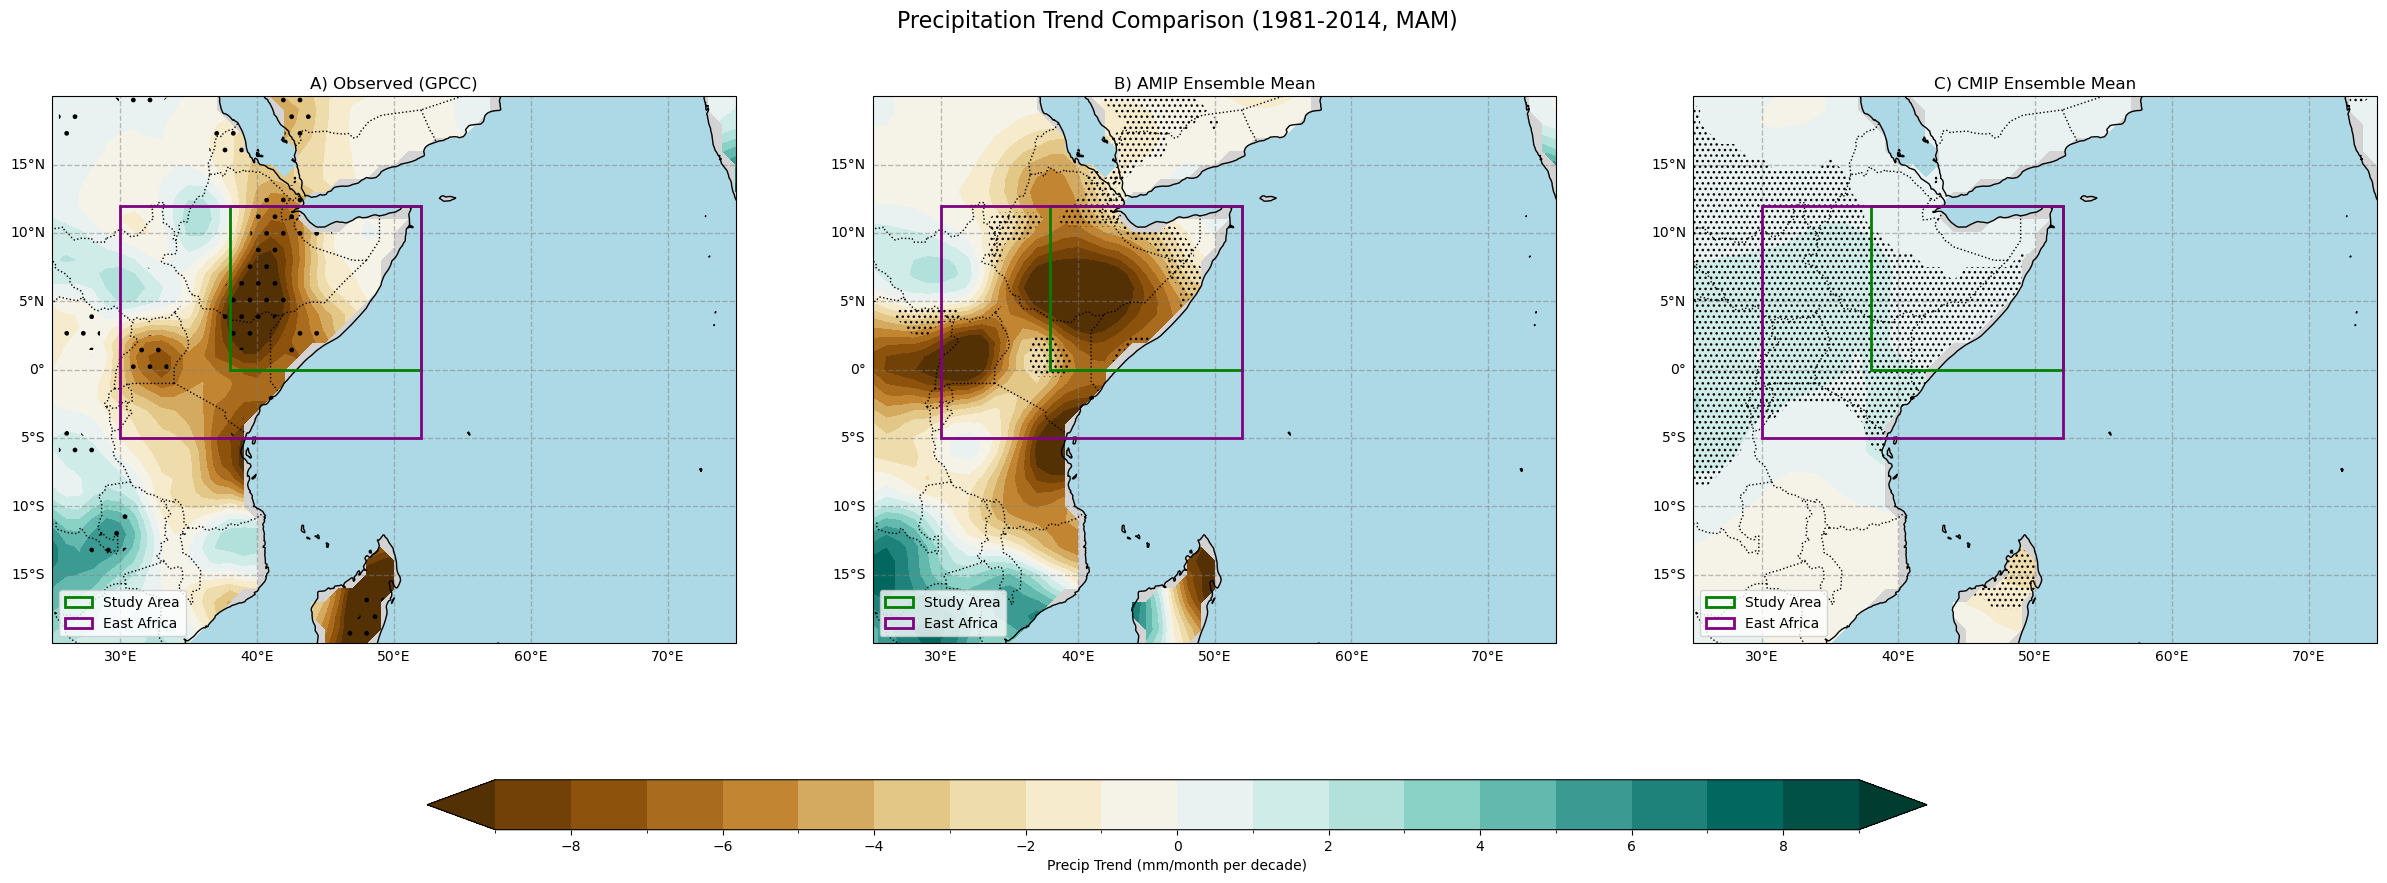

  ✅ Saved and displayed /nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/Fig1_Trend_Comparison_MAM.png

  --- Creating Trend Plot for March ---
    -> Plotting simple significance (p < 0.05)
    -> Plotting FDR significance (q < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)
/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


    -> Plotting ensemble significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


    -> Plotting ensemble significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


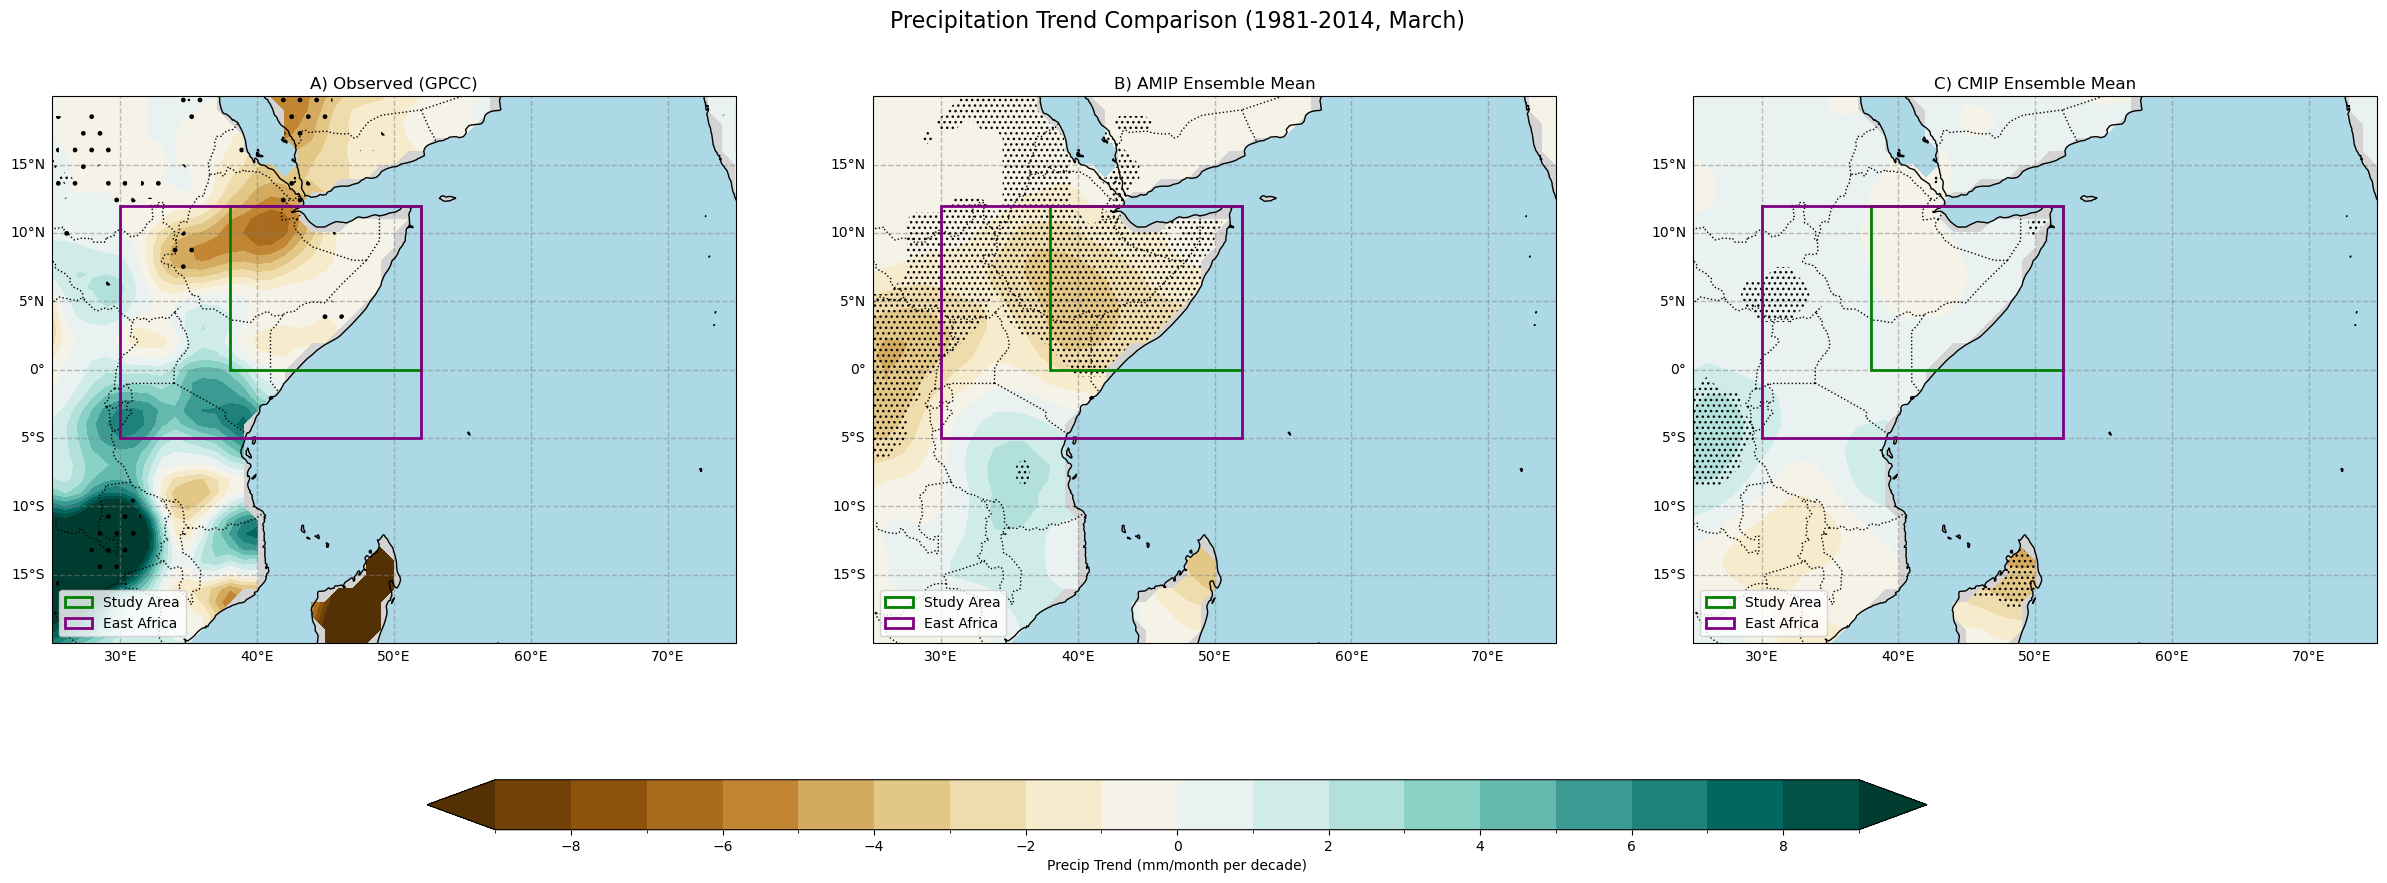

  ✅ Saved and displayed /nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/Fig1_Trend_Comparison_March.png

  --- Creating Trend Plot for April ---
    -> Plotting simple significance (p < 0.05)
    -> Plotting FDR significance (q < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)
/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


    -> Plotting ensemble significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


    -> Plotting ensemble significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


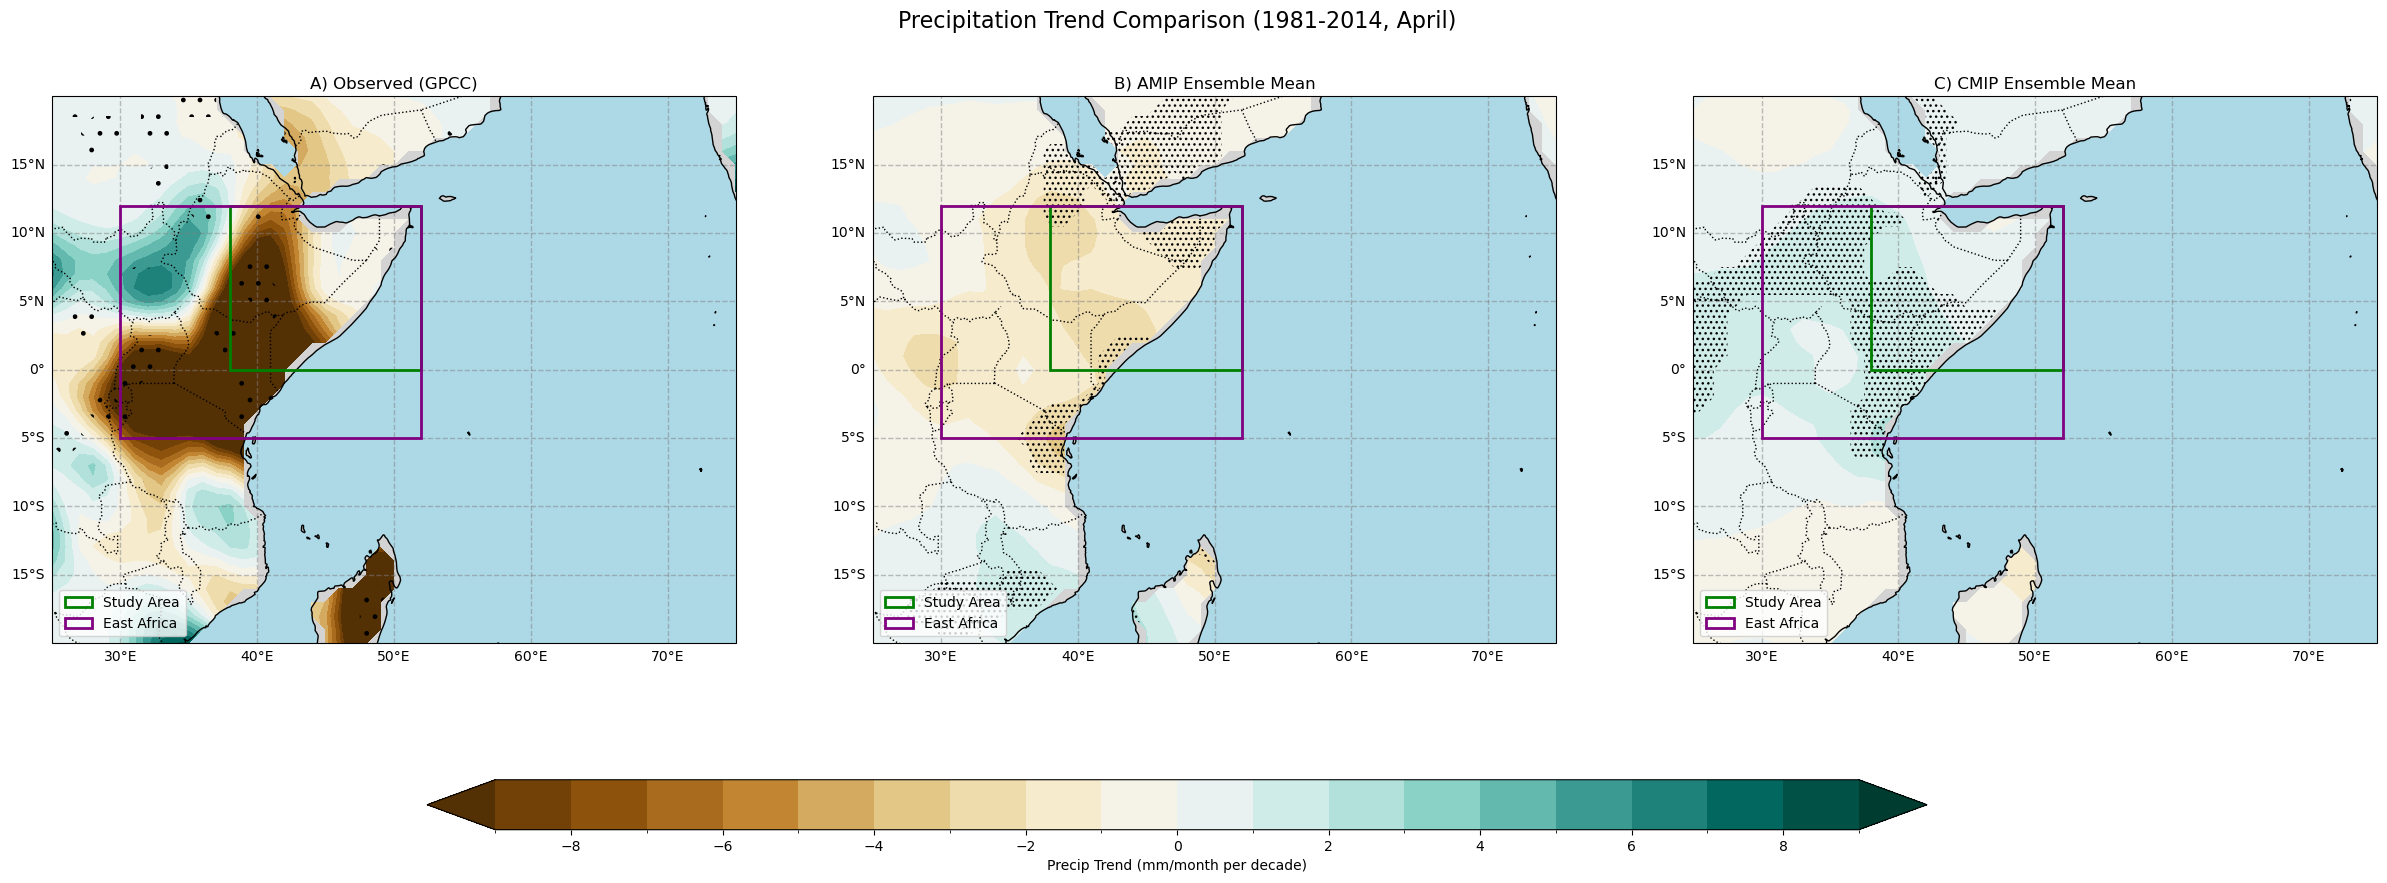

  ✅ Saved and displayed /nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/Fig1_Trend_Comparison_April.png

  --- Creating Trend Plot for May ---
    -> Plotting simple significance (p < 0.05)
    -> Plotting FDR significance (q < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)
/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


    -> Plotting ensemble significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


    -> Plotting ensemble significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


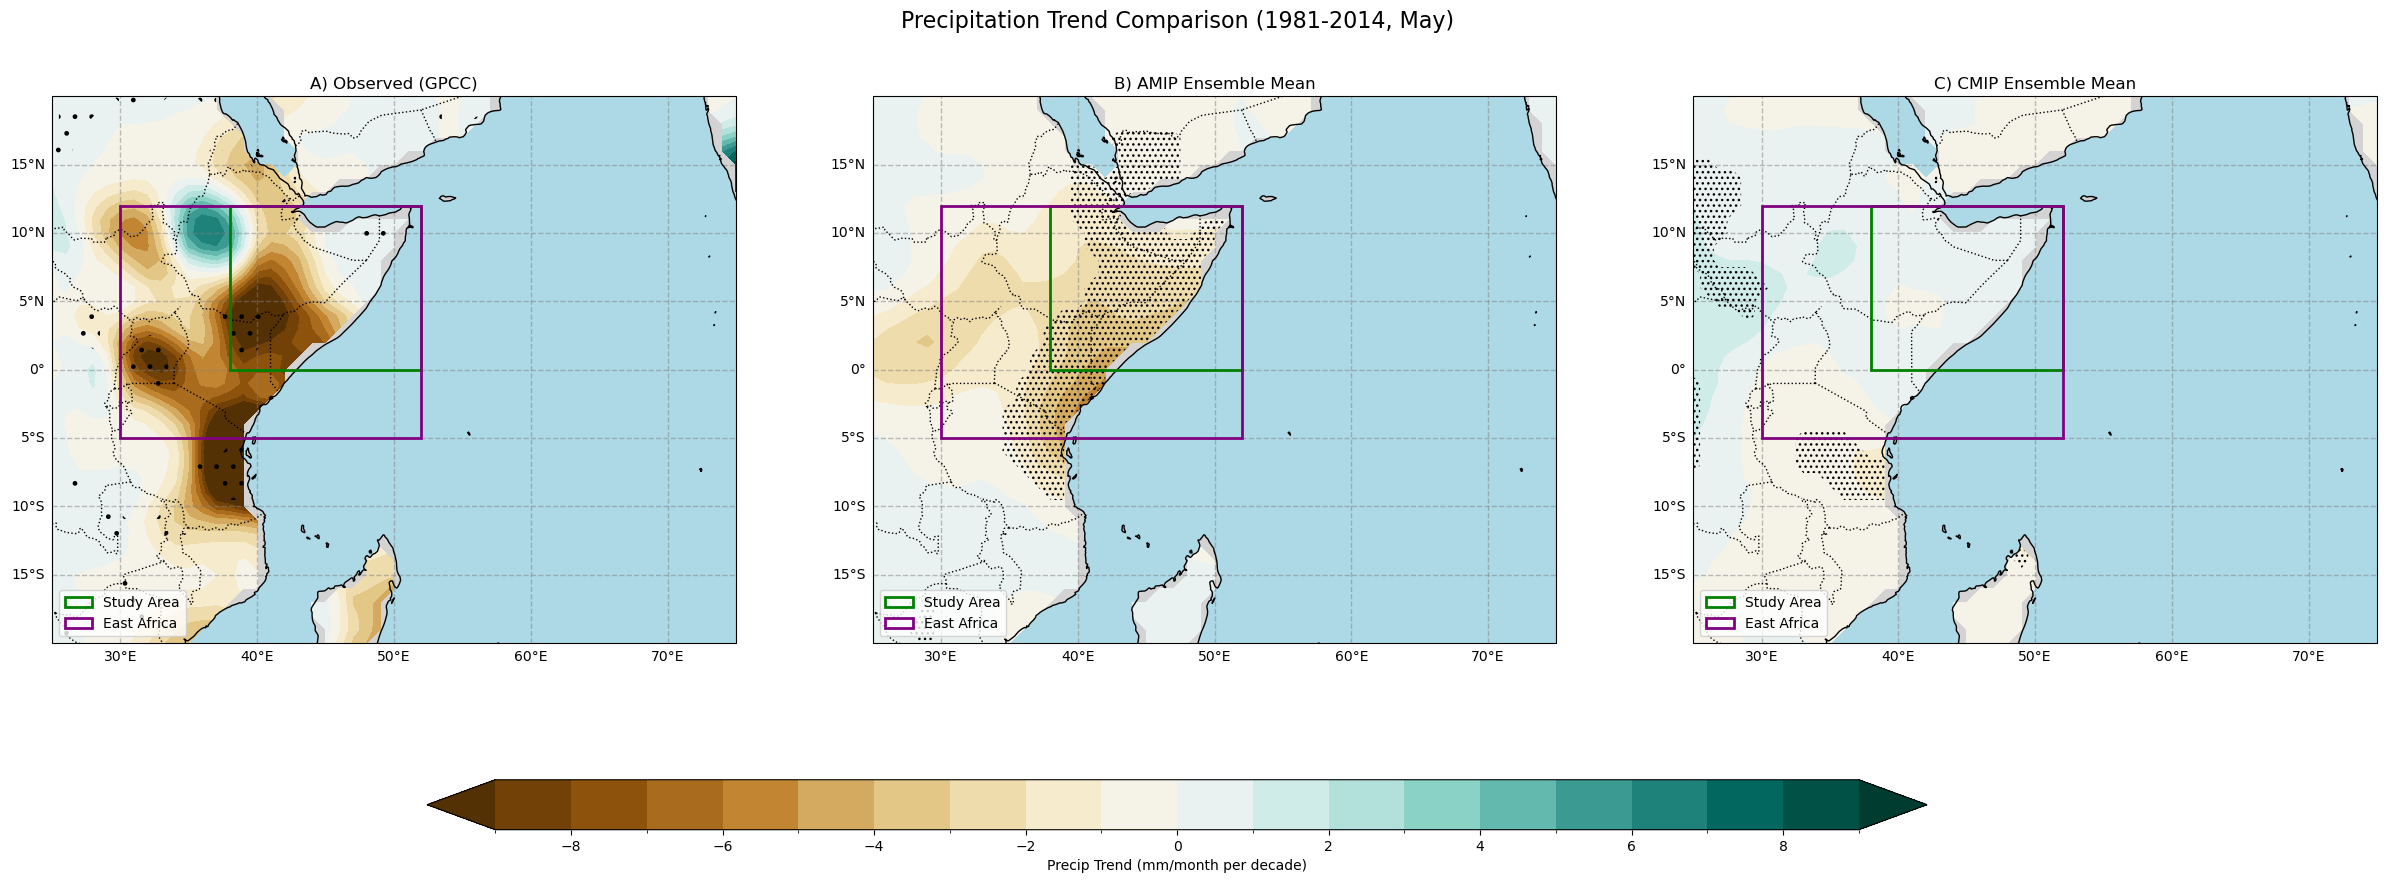

  ✅ Saved and displayed /nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/Fig1_Trend_Comparison_May.png


In [5]:
print("--- 3. Generating Trend Comparison Plots ---")

for period in periods_to_process:
    if period not in obs:
        print(f"\n  SKIPPING PLOTS FOR {period} (Observed data not loaded)")
        continue
    
    print(f"\n  --- Creating Trend Plot for {period} ---")
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(30, 10), subplot_kw={'projection': ccrs.PlateCarree()})
    fig.suptitle(f"Precipitation Trend Comparison ({config.START_YEAR}-{config.END_YEAR}, {period})", fontsize=16, y=0.90)
    
    im_global = None
    
    # Panel A: Obs
    im_obs = alib.create_map_plot(
        axes[0], obs[period]['trend'].where(land_mask), 
        title="A) Observed (GPCC)", cbar_label="Precip Trend (mm/month per decade)", 
        extent=[25, 75, -20, 20], boxes_to_add=['study', 'ea'], add_colorbar=False
    )
    alib.add_significance(axes[0], obs[period]['trend_pval'], fdr_mask=obs[period]['trend_fdr'])
    if im_obs is not None: im_global = im_obs
    
    # Panel B: AMIP
    if period in amip and 'trend_mean' in amip[period]:
        im_amip = alib.create_map_plot(
            axes[1], amip[period]['trend_mean'], 
            title="B) AMIP Ensemble Mean", cbar_label="Precip Trend (mm/month per decade)", 
            extent=[25, 75, -20, 20], boxes_to_add=['study', 'ea'], add_colorbar=False
        )
        alib.add_ensemble_significance(axes[1], amip[period]['trend_sig'])
        if im_global is None and im_amip is not None: im_global = im_amip
    else:
        axes[1].text(0.5, 0.5, 'AMIP data not found', ha='center', transform=axes[1].transAxes)

    # Panel C: CMIP
    if period in cmip and 'trend_mean' in cmip[period]:
        im_cmip = alib.create_map_plot(
            axes[2], cmip[period]['trend_mean'], 
            title="C) CMIP Ensemble Mean", cbar_label="Precip Trend (mm/month per decade)", 
            extent=[25, 75, -20, 20], boxes_to_add=['study', 'ea'], add_colorbar=False
        )
        alib.add_ensemble_significance(axes[2], cmip[period]['trend_sig'])
        if im_global is None and im_cmip is not None: im_global = im_cmip
    else:
        axes[2].set_title("C) CMIP Ensemble Mean (Data not found)")
        axes[2].text(0.5, 0.5, 'CMIP data not found', ha='center', transform=axes[2].transAxes)
        
    # Draw shared horizontal colorbar
    if im_global is not None:
        cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.05]) 
        cbar = fig.colorbar(im_global, cax=cbar_ax, orientation='horizontal')
        cbar.set_label("Precip Trend (mm/month per decade)")

    plt.subplots_adjust(bottom=0.20) 
    fig_path = fig_dir / f"Fig1_Trend_Comparison_{period}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"  ✅ Saved and displayed {fig_path}")

--- 3. Generating Combined Trend Comparison Master Plot (Study Area Only) ---
  -> Adding MAM to row 1...
    -> Plotting simple significance (p < 0.05)
    -> Plotting FDR significance (q < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)
/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


    -> Plotting ensemble significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


    -> Plotting ensemble significance (p < 0.05)
  -> Adding March to row 2...
    -> Plotting simple significance (p < 0.05)
    -> Plotting FDR significance (q < 0.05)


...

/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)
/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)
/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


    -> Plotting ensemble significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


    -> Plotting ensemble significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


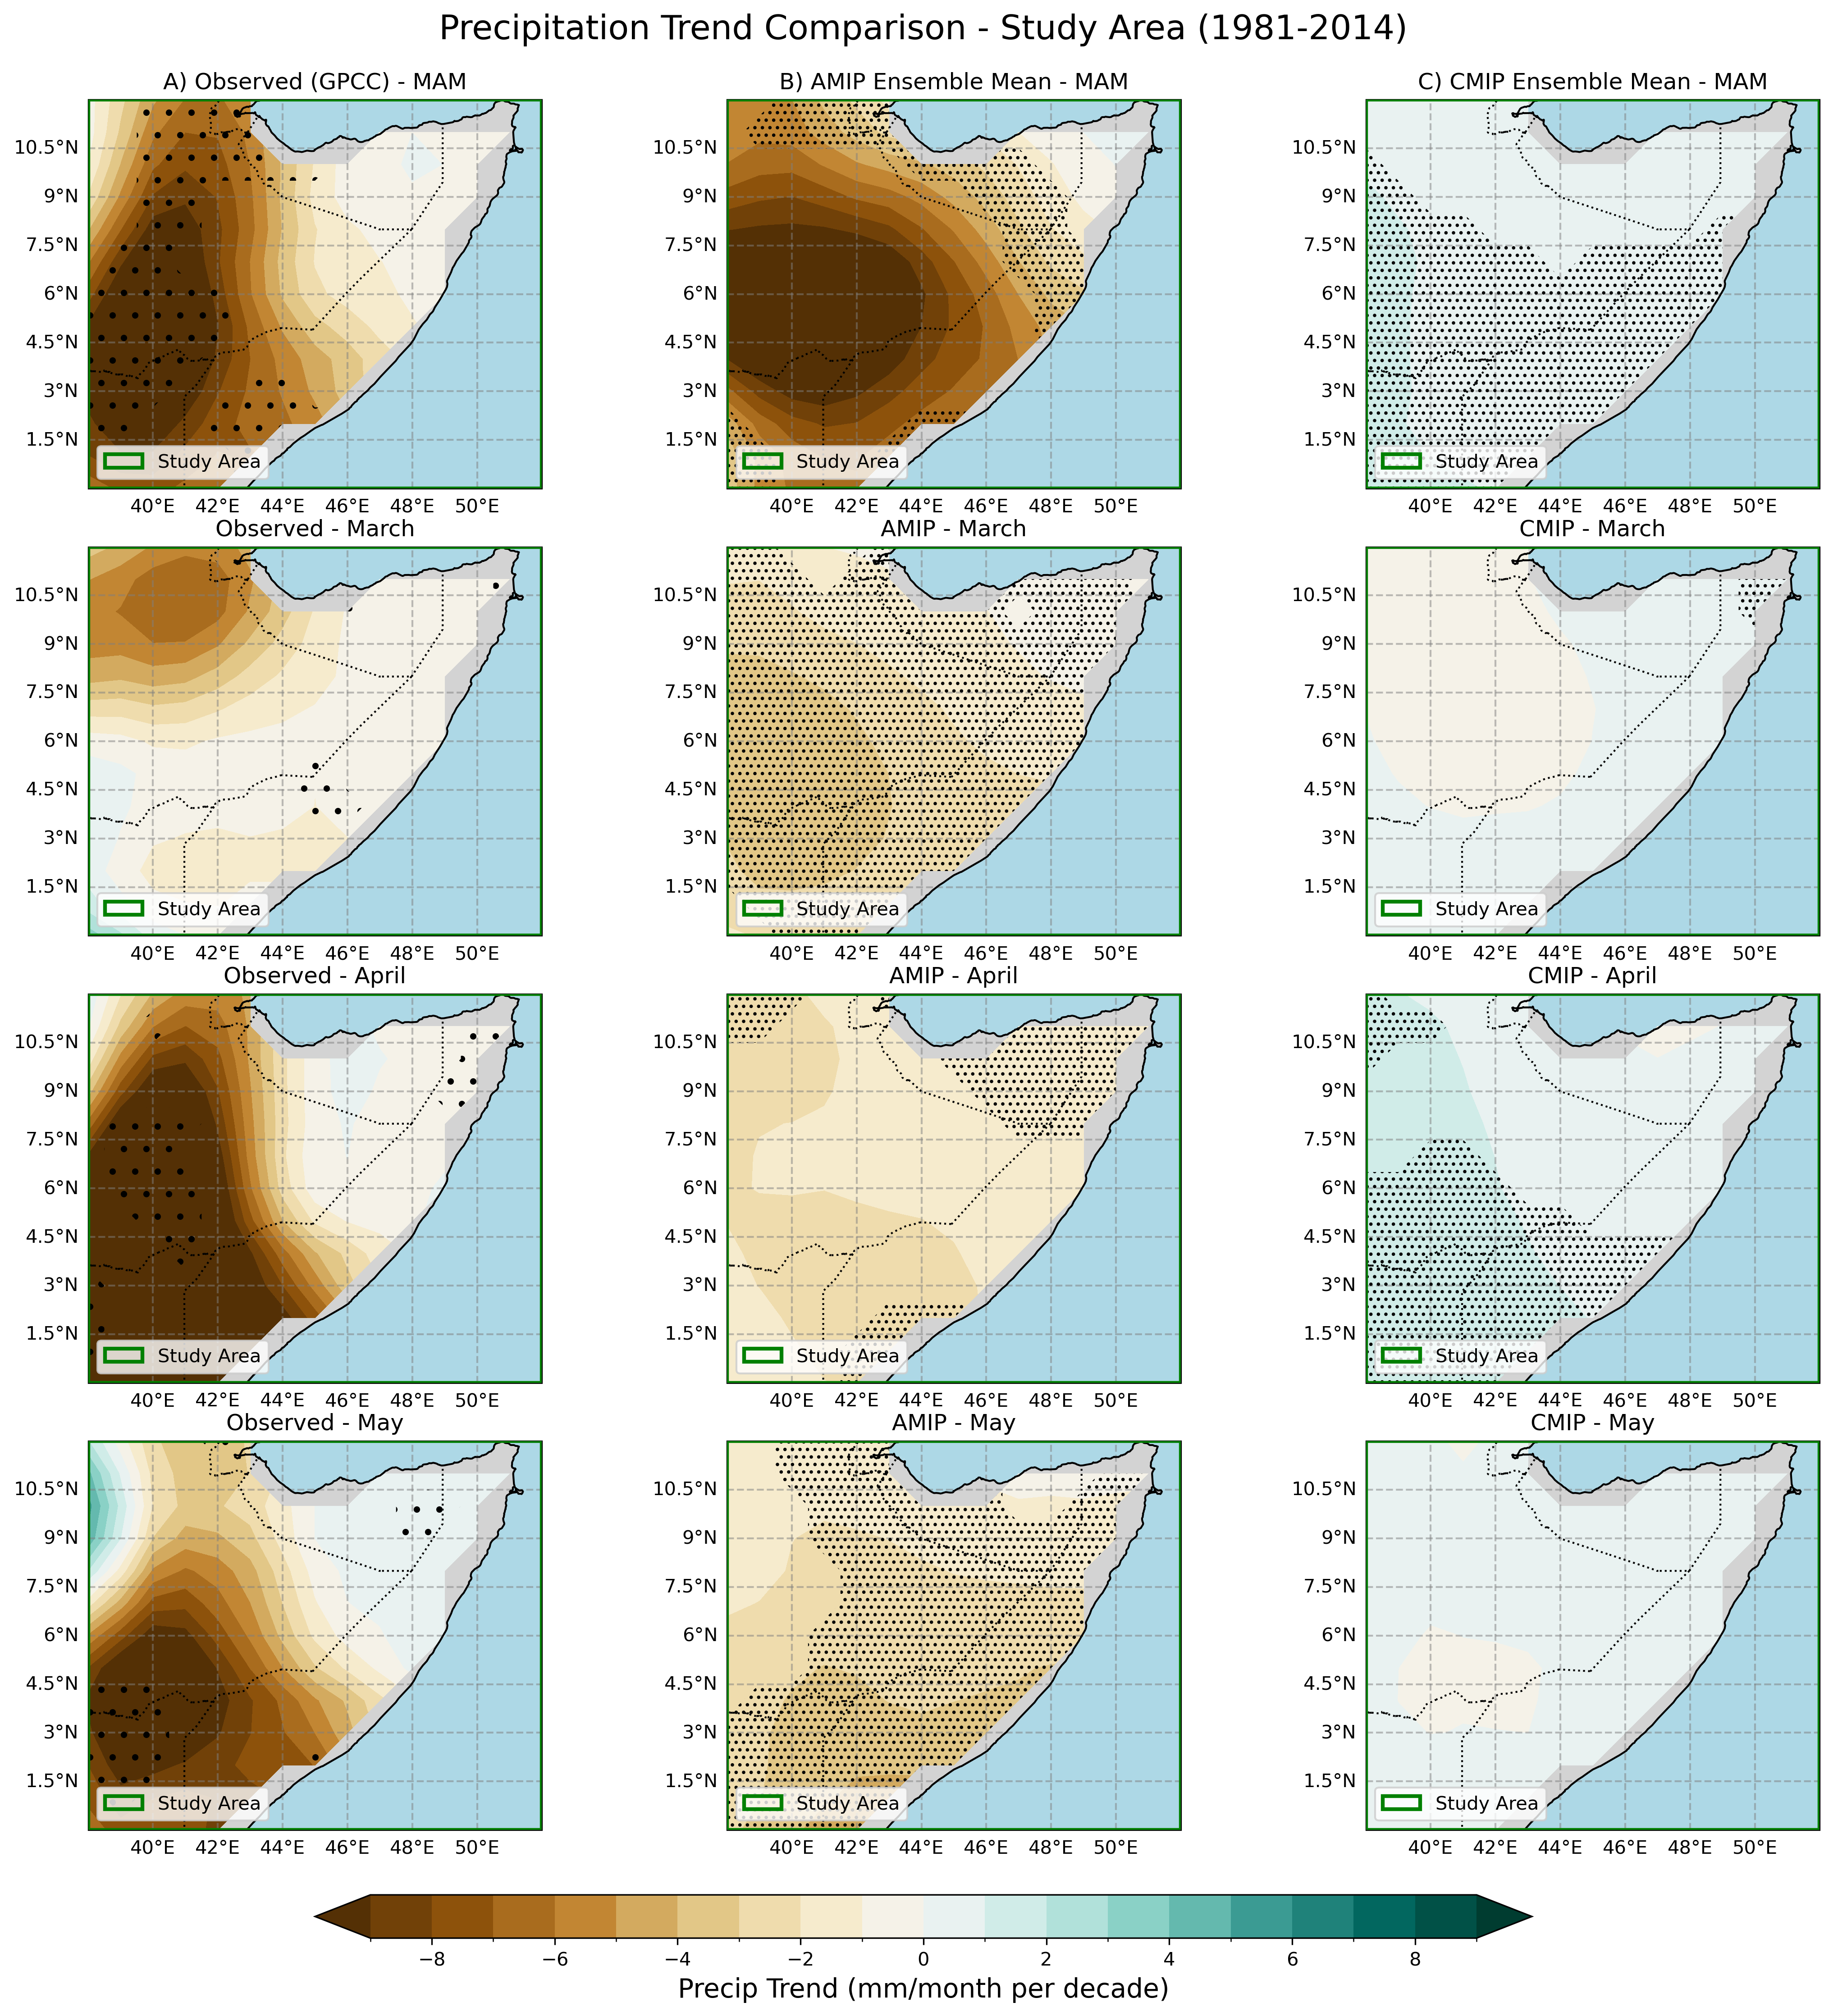

✅ Saved and displayed study-area master plot: /nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/Fig1_Combined_Trend_Comparison_StudyArea.png


In [6]:
print("--- 3. Generating Combined Trend Comparison Master Plot (Study Area Only) ---")

num_periods = len(periods_to_process)

# Extract study area bounding box: [lon_min, lon_max, lat_min, lat_max]
study_bounds = config.BOUNDS['study']
study_extent = [
    study_bounds['lon_min'], 
    study_bounds['lon_max'], 
    study_bounds['lat_min'], 
    study_bounds['lat_max']
]

# Create a master grid: rows = periods, cols = 3 (Obs, AMIP, CMIP)
fig, axes = plt.subplots(
    nrows=num_periods,
    dpi=300, 
    ncols=3, 
    figsize=(18, 4 * num_periods),  # Slightly adjusted aspect ratio for localized extent
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Ensure axes is always a 2D array even if num_periods == 1
if num_periods == 1:
    axes = np.expand_dims(axes, axis=0)

fig.suptitle(f"Precipitation Trend Comparison - Study Area ({config.START_YEAR}-{config.END_YEAR})", fontsize=18, y=0.92)

im_global = None

for i, period in enumerate(periods_to_process):
    print(f"  -> Adding {period} to row {i+1}...")
    
    ax_obs = axes[i, 0]
    ax_amip = axes[i, 1]
    ax_cmip = axes[i, 2]
    
    if period not in obs:
        print(f"     SKIPPING {period} (Observed data not loaded)")
        for ax in [ax_obs, ax_amip, ax_cmip]:
            ax.text(0.5, 0.5, f'No data for {period}', ha='center', transform=ax.transAxes)
        continue

    # Panel A: Obs (Left Column)
    im_obs = alib.create_map_plot(
        ax_obs, obs[period]['trend'].where(land_mask), 
        title=f"A) Observed (GPCC) - {period}" if i == 0 else f"Observed - {period}", 
        cbar_label="Precip Trend (mm/month per decade)", 
        extent=study_extent, boxes_to_add=['study'], add_colorbar=False
    )
    alib.add_significance(ax_obs, obs[period]['trend_pval'], fdr_mask=obs[period]['trend_fdr'])
    if im_obs is not None: im_global = im_obs
    
    # Panel B: AMIP (Middle Column)
    if period in amip and 'trend_mean' in amip[period]:
        im_amip = alib.create_map_plot(
            ax_amip, amip[period]['trend_mean'], 
            title=f"B) AMIP Ensemble Mean - {period}" if i == 0 else f"AMIP - {period}", 
            cbar_label="Precip Trend (mm/month per decade)", 
            extent=study_extent, boxes_to_add=['study'], add_colorbar=False
        )
        alib.add_ensemble_significance(ax_amip, amip[period]['trend_sig'])
        if im_global is None and im_amip is not None: im_global = im_amip
    else:
        ax_amip.set_title(f"AMIP - {period}")
        ax_amip.text(0.5, 0.5, 'AMIP data not found', ha='center', transform=ax_amip.transAxes)

    # Panel C: CMIP (Right Column)
    if period in cmip and 'trend_mean' in cmip[period]:
        im_cmip = alib.create_map_plot(
            ax_cmip, cmip[period]['trend_mean'], 
            title=f"C) CMIP Ensemble Mean - {period}" if i == 0 else f"CMIP - {period}", 
            cbar_label="Precip Trend (mm/month per decade)", 
            extent=study_extent, boxes_to_add=['study'], add_colorbar=False
        )
        alib.add_ensemble_significance(ax_cmip, cmip[period]['trend_sig'])
        if im_global is None and im_cmip is not None: im_global = im_cmip
    else:
        ax_cmip.set_title(f"CMIP - {period}")
        ax_cmip.text(0.5, 0.5, 'CMIP data not found', ha='center', transform=ax_cmip.transAxes)

# Adjust spacing between subplots
plt.subplots_adjust(bottom=0.08, hspace=0.15, wspace=0.05) 

# Draw shared horizontal colorbar
if im_global is not None:
    cbar_ax = fig.add_axes([0.25, 0.03, 0.5, 0.02]) 
    cbar = fig.colorbar(im_global, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("Precip Trend (mm/month per decade)", fontsize=14)

fig_path = fig_dir / "Fig1_Combined_Trend_Comparison_StudyArea.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Saved and displayed study-area master plot: {fig_path}")

In [7]:
print("--- 6. Extracting Numerical Trend Significance Values ---")

trend_summary_data = []
alpha = 0.05  # Significance threshold
region_name = 'study'  # Change to any region defined in config.BOUNDS

# Helper function to compute percentage of significant grid cells
def get_significant_stats(trend_map, pval_map, region, threshold=0.05):
    b = config.BOUNDS[region]
    
    # Slice to region
    r_trend = trend_map.sel(lat=slice(b['lat_min'], b['lat_max']), lon=slice(b['lon_min'], b['lon_max']))
    r_pval = pval_map.sel(lat=slice(b['lat_min'], b['lat_max']), lon=slice(b['lon_min'], b['lon_max']))
    
    # Count valid (non-NaN) grid cells
    total_valid_cells = r_trend.notnull().sum().compute().item()
    if total_valid_cells == 0:
        return np.nan, 0.0, np.nan
        
    # Filter for statistically significant cells
    sig_mask = (r_pval < threshold) & r_trend.notnull()
    sig_cell_count = sig_mask.sum().compute().item()
    pct_significant = (sig_cell_count / total_valid_cells) * 100.0
    
    # Mean trend of ONLY the significant cells
    sig_trend_mean = r_trend.where(sig_mask).mean().compute().item()
    
    return pct_significant, sig_trend_mean

for period in periods_to_process:
    # 1. Observed (GPCC)
    if period in obs and 'trend' in obs[period]:
        obs_trend = obs[period]['trend'].where(land_mask)
        obs_pval = obs[period]['trend_pval'].where(land_mask)
        
        mean_trend = get_regional_mean(obs_trend, region_name)
        mean_pval = get_regional_mean(obs_pval, region_name)
        pct_sig, sig_mean_trend = get_significant_stats(obs_trend, obs_pval, region_name, alpha)
        
        trend_summary_data.append({
            'Period': period,
            'Dataset': 'Observed (GPCC)',
            'Regional_Mean_Trend': round(mean_trend, 4),
            'Regional_Mean_Pval': round(mean_pval, 4),
            'Is_Region_Significant (p<0.05)': mean_pval < alpha,
            'Significant_Area_Pct (%)': round(pct_sig, 1),
            'Mean_Of_Significant_Cells_Only': round(sig_mean_trend, 4) if pd.notnull(sig_mean_trend) else np.nan
        })

    # 2. AMIP Ensemble Mean
    if period in amip and 'trend_mean' in amip[period]:
        amip_trend = amip[period]['trend_mean']
        amip_pval = amip[period]['trend_sig']  # Note: trend_sig holds the t-test p-values
        
        mean_trend = get_regional_mean(amip_trend, region_name)
        mean_pval = get_regional_mean(amip_pval, region_name)
        pct_sig, sig_mean_trend = get_significant_stats(amip_trend, amip_pval, region_name, alpha)
        
        trend_summary_data.append({
            'Period': period,
            'Dataset': 'AMIP Ensemble',
            'Regional_Mean_Trend': round(mean_trend, 4),
            'Regional_Mean_Pval': round(mean_pval, 4),
            'Is_Region_Significant (p<0.05)': mean_pval < alpha,
            'Significant_Area_Pct (%)': round(pct_sig, 1),
            'Mean_Of_Significant_Cells_Only': round(sig_mean_trend, 4) if pd.notnull(sig_mean_trend) else np.nan
        })

    # 3. CMIP Ensemble Mean
    if period in cmip and 'trend_mean' in cmip[period]:
        cmip_trend = cmip[period]['trend_mean']
        cmip_pval = cmip[period]['trend_sig']
        
        mean_trend = get_regional_mean(cmip_trend, region_name)
        mean_pval = get_regional_mean(cmip_pval, region_name)
        pct_sig, sig_mean_trend = get_significant_stats(cmip_trend, cmip_pval, region_name, alpha)
        
        trend_summary_data.append({
            'Period': period,
            'Dataset': 'CMIP Ensemble',
            'Regional_Mean_Trend': round(mean_trend, 4),
            'Regional_Mean_Pval': round(mean_pval, 4),
            'Is_Region_Significant (p<0.05)': mean_pval < alpha,
            'Significant_Area_Pct (%)': round(pct_sig, 1),
            'Mean_Of_Significant_Cells_Only': round(sig_mean_trend, 4) if pd.notnull(sig_mean_trend) else np.nan
        })

# Create and display the summary DataFrame
df_trend_sig = pd.DataFrame(trend_summary_data)

# Export to CSV alongside your other data
trend_csv_path = csv_dir / f"numerical_trend_significance_{region_name}.csv"
df_trend_sig.to_csv(trend_csv_path, index=False)
print(f"✅ Saved numerical trend significance table to {trend_csv_path}\n")

# Display in notebook
df_trend_sig

--- 6. Extracting Numerical Trend Significance Values ---


✅ Saved numerical trend significance table to /nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/csv_data/numerical_trend_significance_study.csv



,Period,Dataset,Regional_Mean_Trend,Regional_Mean_Pval,Is_Region_Significant (p<0.05),Significant_Area_Pct (%),Mean_Of_Significant_Cells_Only
0,MAM,Observed (GPCC),-5.3602,0.2736,False,35.9,-8.3424
1,MAM,AMIP Ensemble,-6.4533,0.1324,False,25.0,-3.8373
2,MAM,CMIP Ensemble,0.6620,0.0587,False,62.5,0.8301
3,March,Observed (GPCC),-1.7063,0.4912,False,5.5,-1.9982
4,March,AMIP Ensemble,-2.2215,0.0217,True,93.0,-2.2872
5,March,CMIP Ensemble,0.0354,0.6108,False,2.3,0.1658
6,April,Observed (GPCC),-6.8920,0.3475,False,16.4,-10.6472
7,April,AMIP Ensemble,-1.8882,0.1420,False,24.2,-1.7159
8,April,CMIP Ensemble,0.8430,0.2066,False,44.5,1.2403
9,May,Observed (GPCC),-3.9940,0.3768,False,11.7,-7.2758


--- 4. Generating Teleconnection Maps ---

  --- Creating Teleconnection Plot for MAM ---
    -> Plotting simple significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


    -> Plotting ensemble significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


    -> Plotting ensemble significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


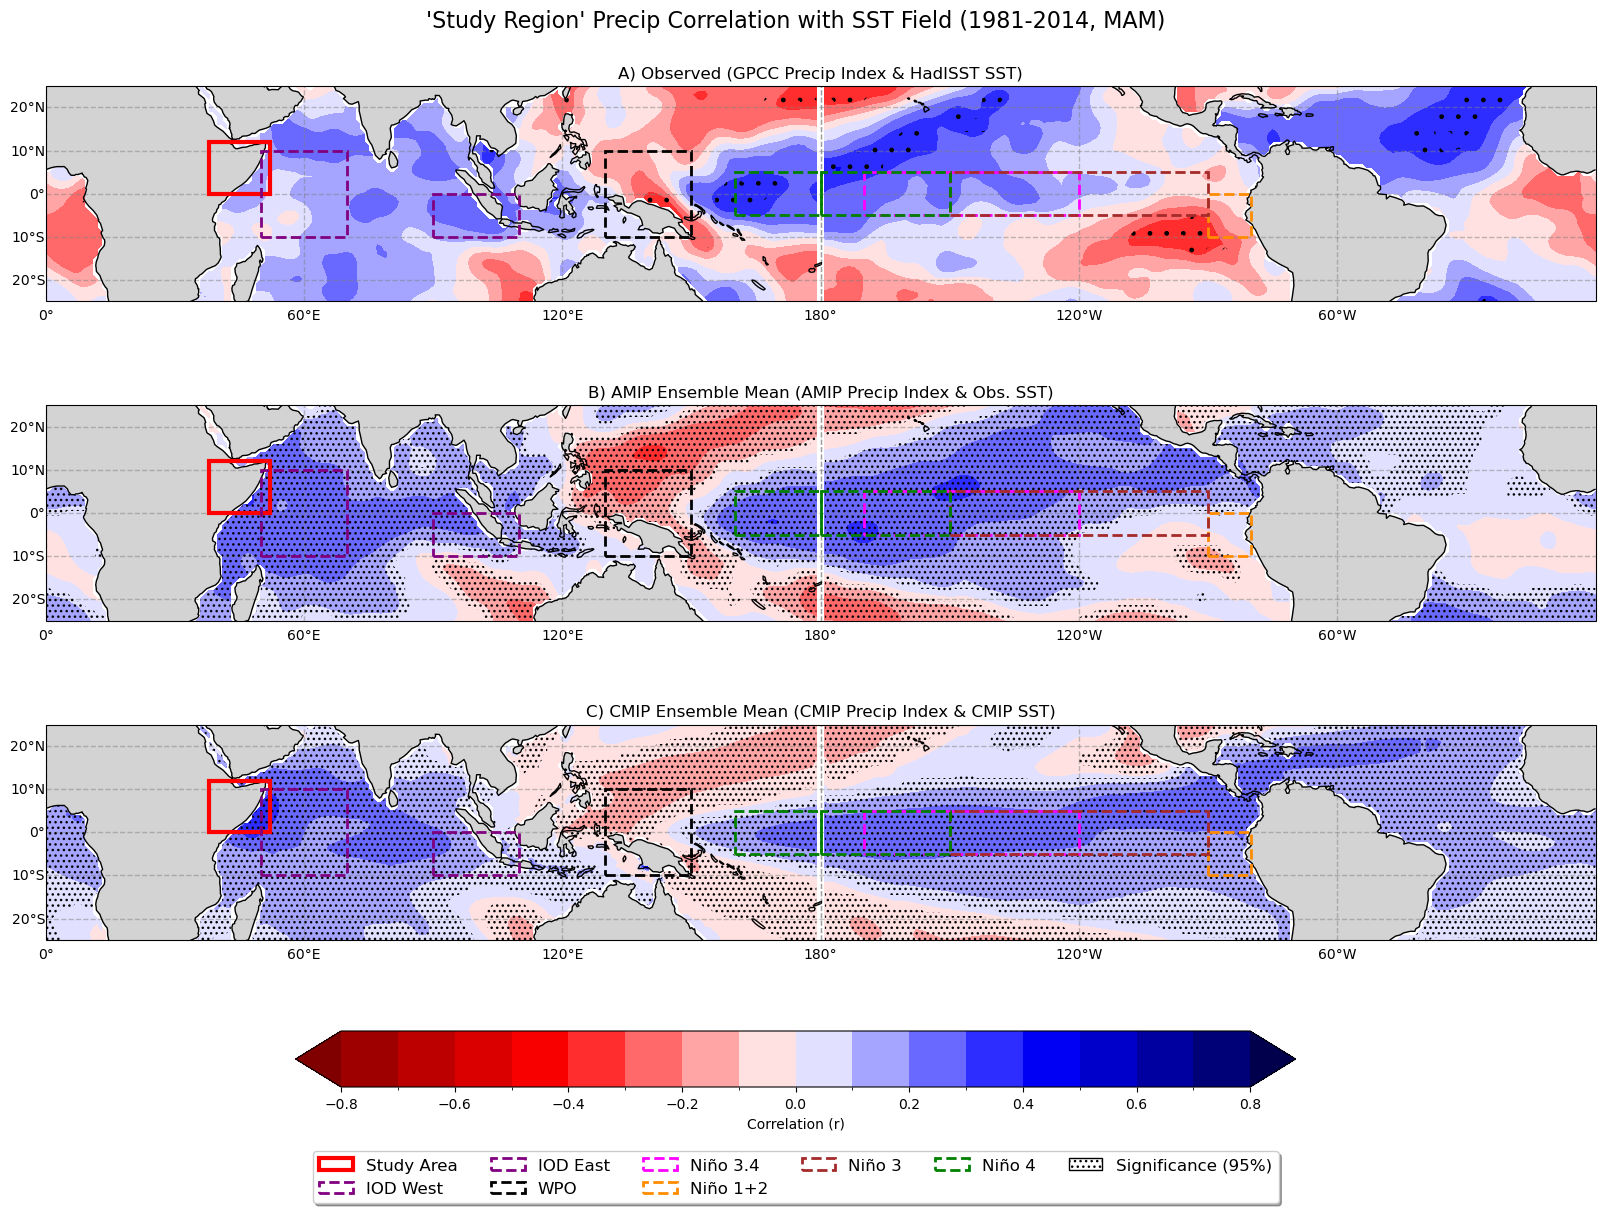

  ✅ Saved and displayed /nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/Fig_Teleconnection_PrecipIndex_vs_SST_MAM.png

  --- Creating Teleconnection Plot for March ---
    -> Plotting simple significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


    -> Plotting ensemble significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


    -> Plotting ensemble significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


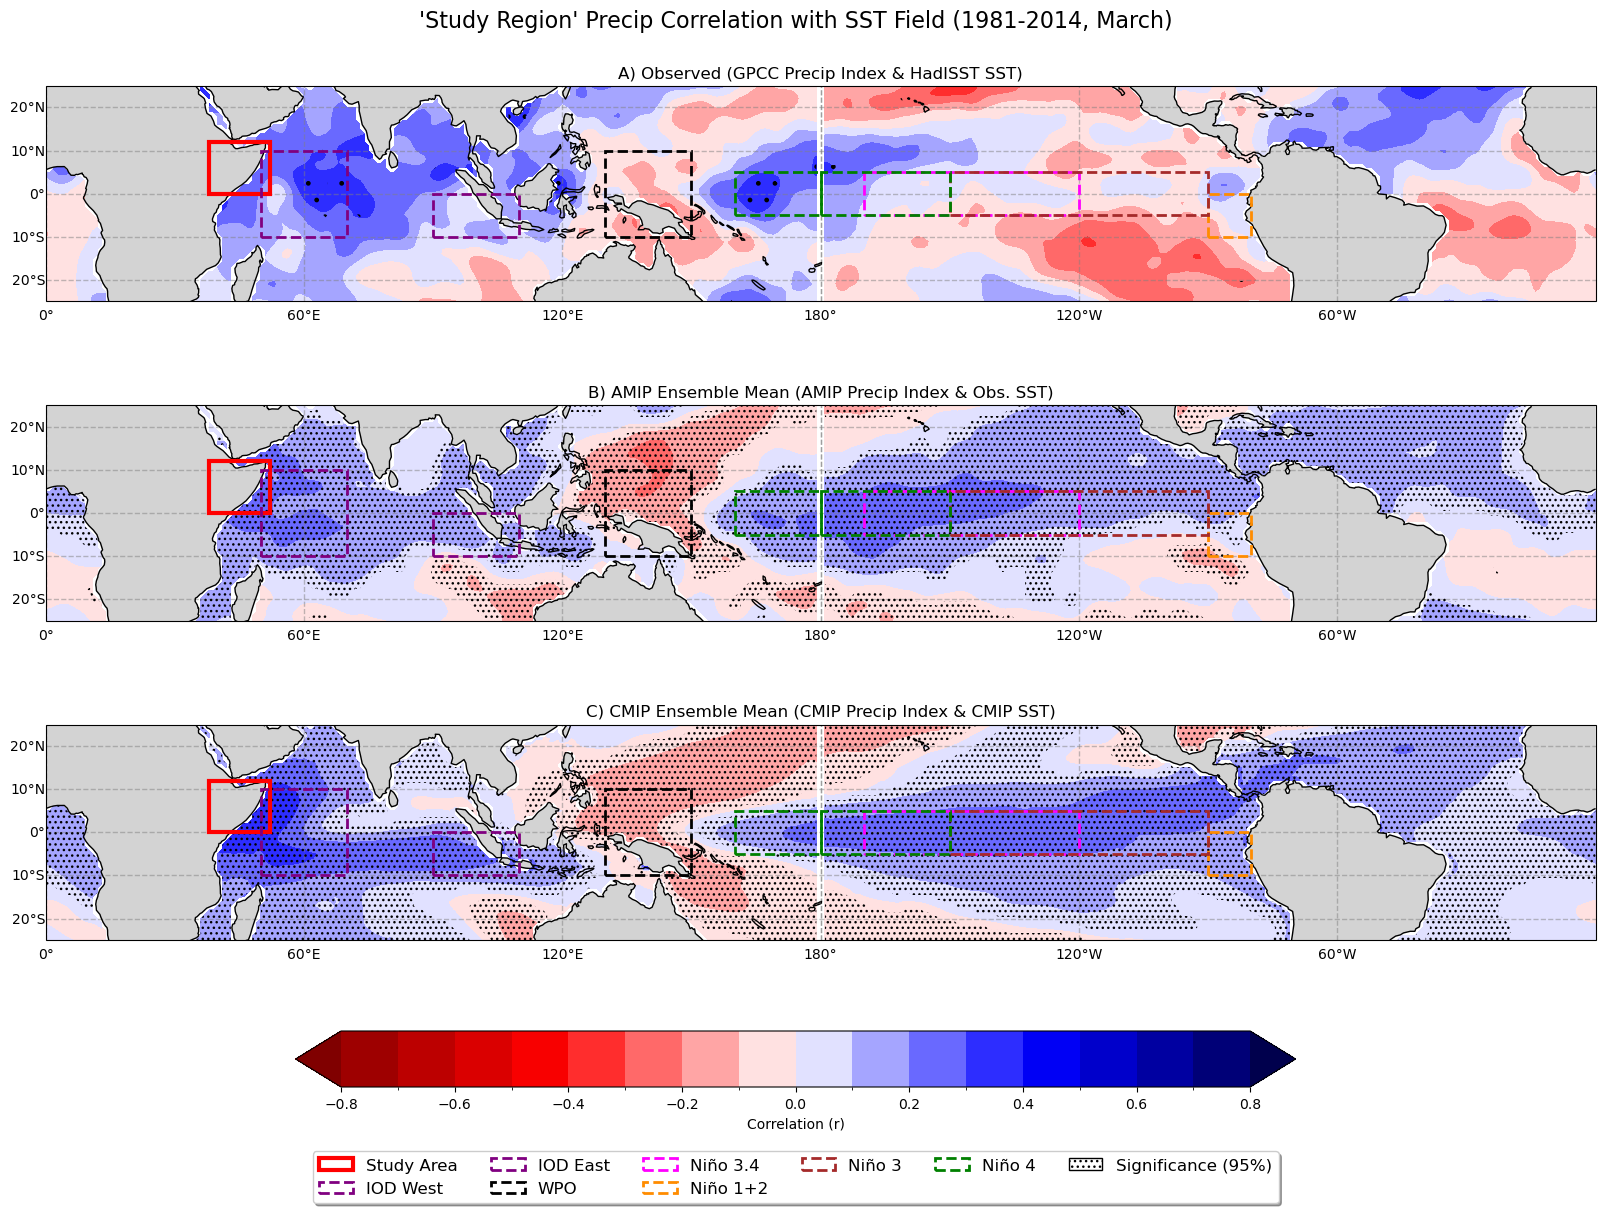

  ✅ Saved and displayed /nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/Fig_Teleconnection_PrecipIndex_vs_SST_March.png

  --- Creating Teleconnection Plot for April ---
    -> Plotting simple significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


    -> Plotting ensemble significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


    -> Plotting ensemble significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


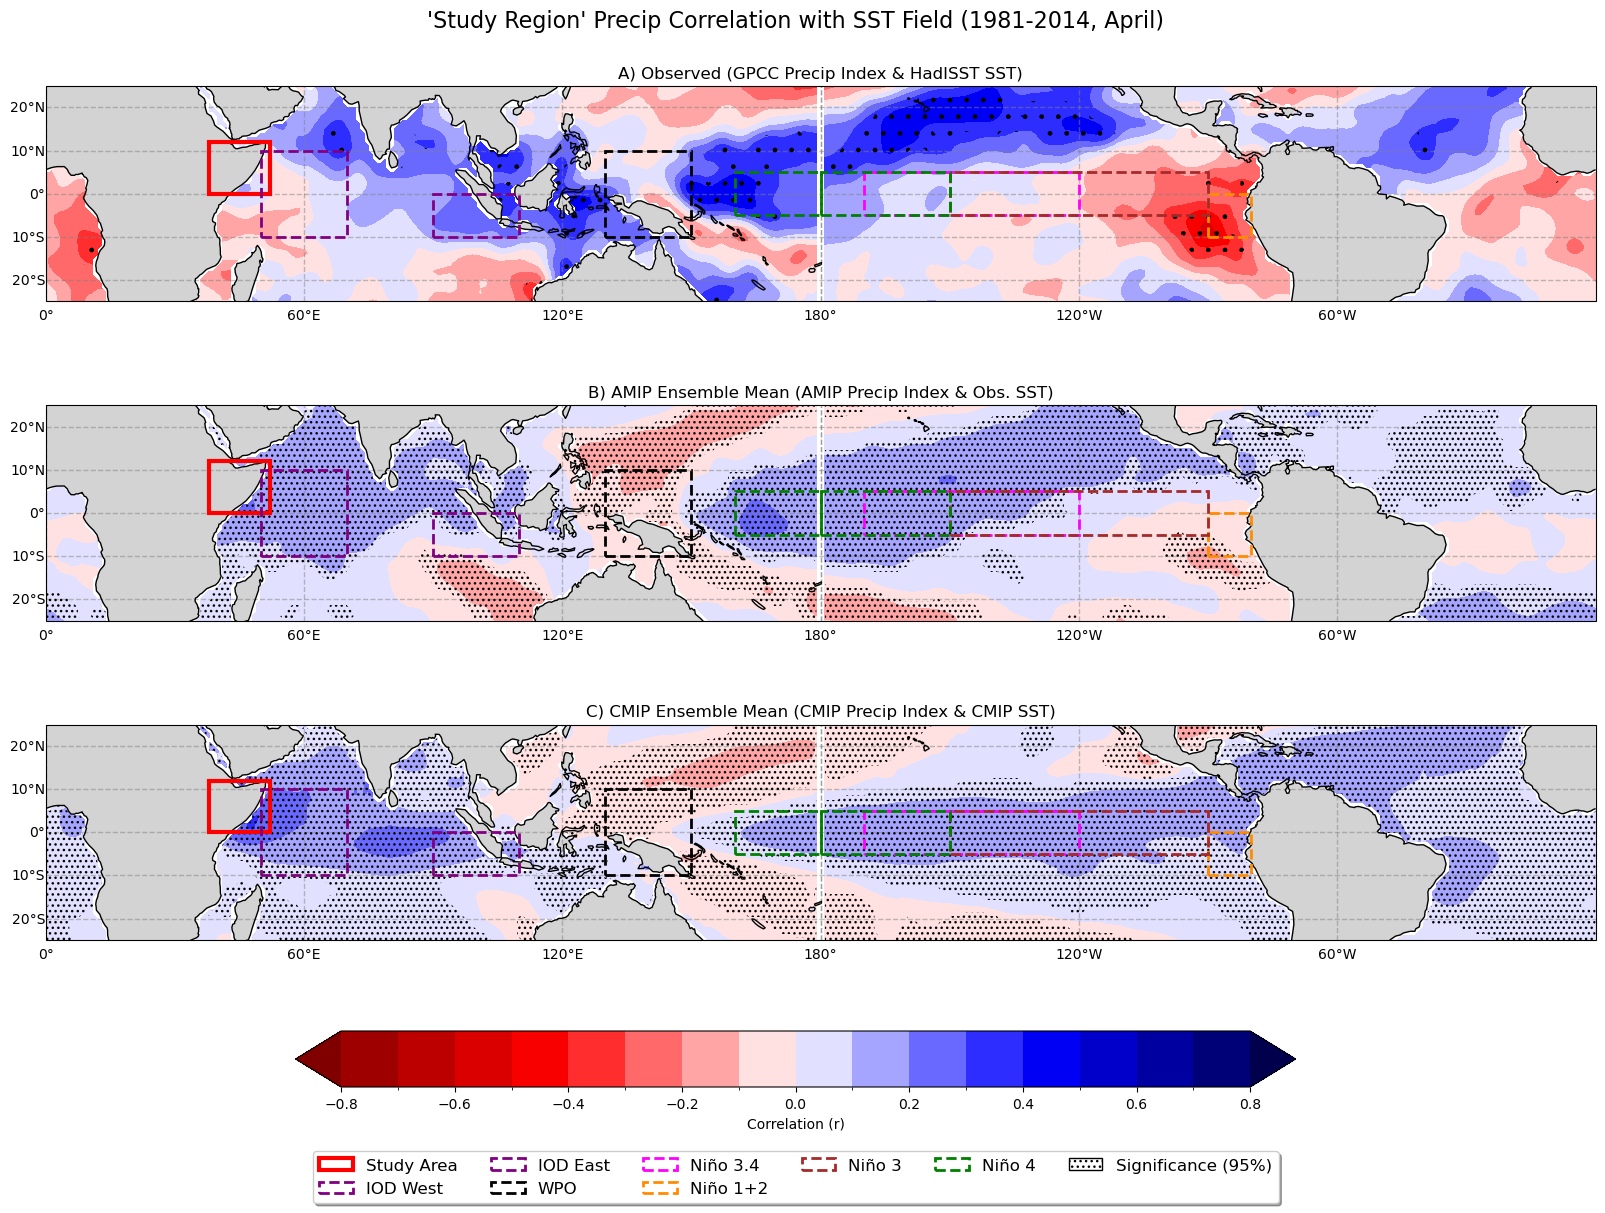

  ✅ Saved and displayed /nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/Fig_Teleconnection_PrecipIndex_vs_SST_April.png

  --- Creating Teleconnection Plot for May ---
    -> Plotting simple significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


    -> Plotting ensemble significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


    -> Plotting ensemble significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


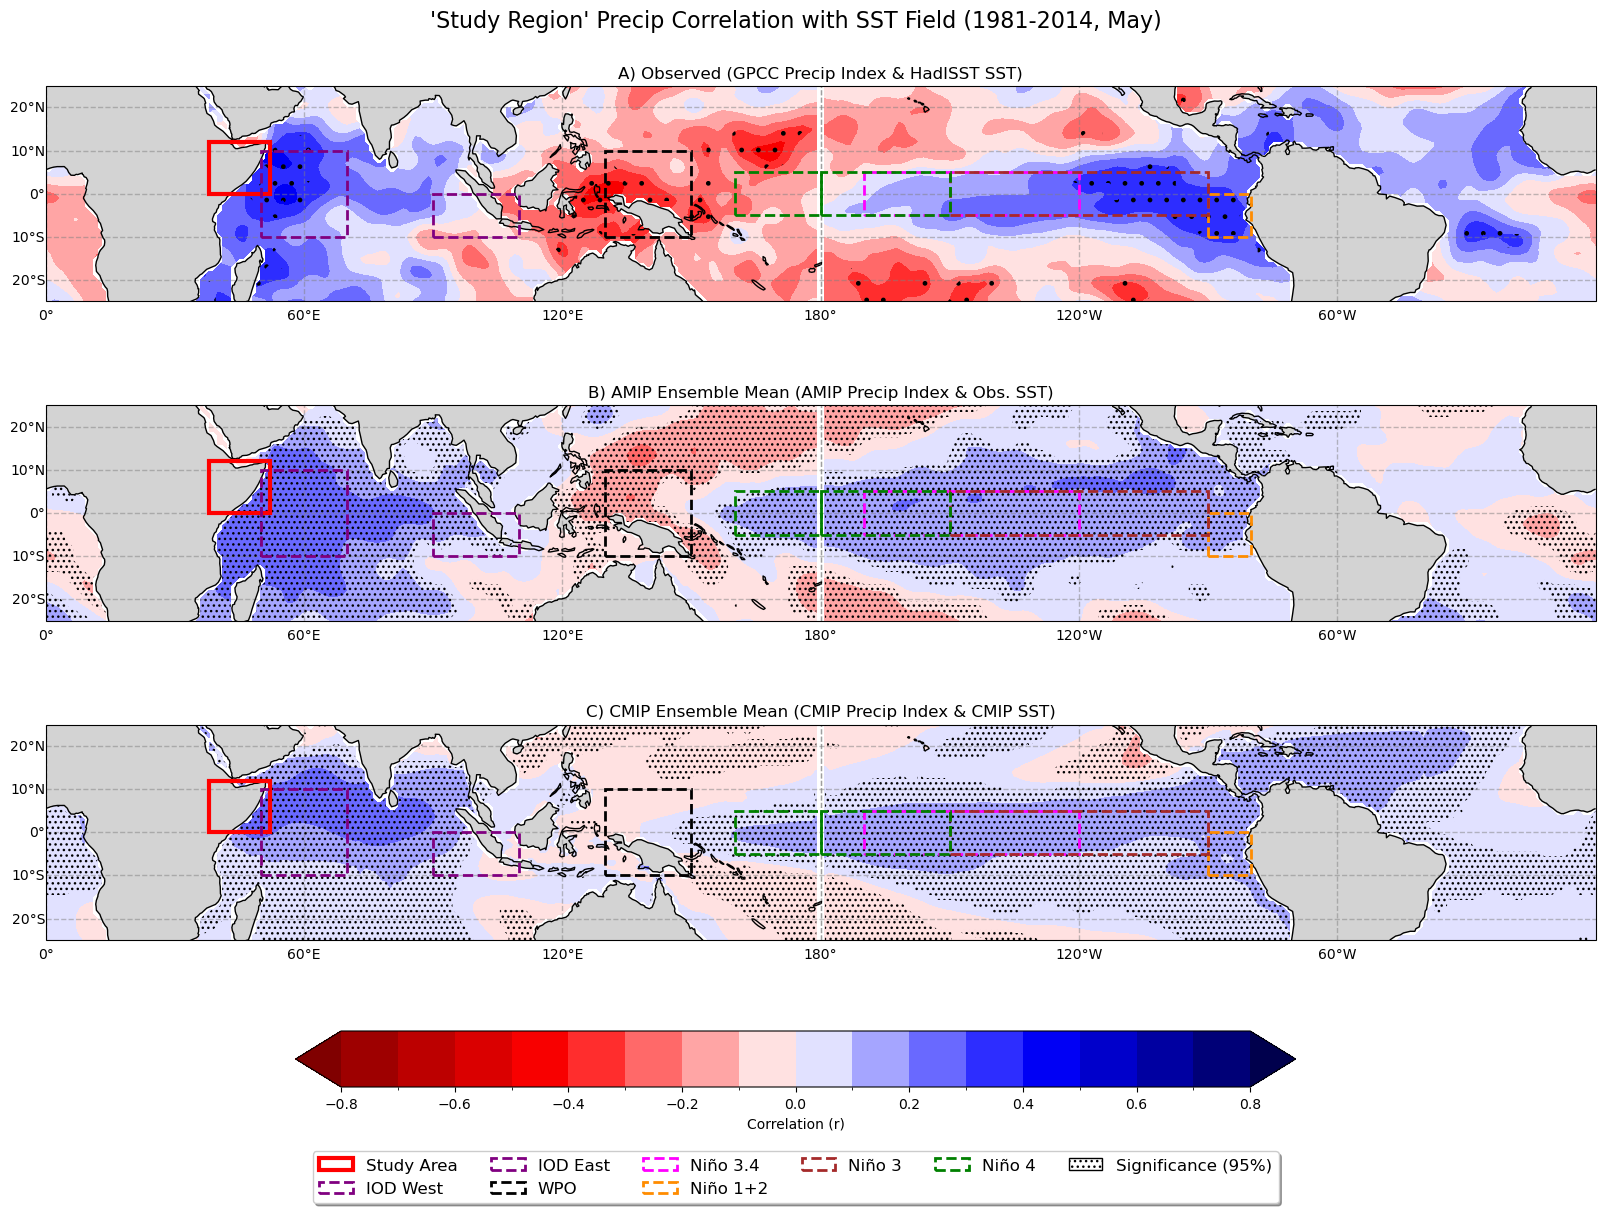

  ✅ Saved and displayed /nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/Fig_Teleconnection_PrecipIndex_vs_SST_May.png


In [8]:
print("--- 4. Generating Teleconnection Maps ---")

reference_key = "tele_sst_IOD" 
boxes_to_draw = ['study', 'wio', 'eio', 'wpo', 'nino34', 'nino12', 'nino3', 'nino4']
plot_extent = [-180, 180, -25, 25] 

for period in periods_to_process:
    if period not in obs or reference_key not in obs[period]:
        print(f"  ⚠️ Skipping Teleconnection plot for {period}, data was not loaded.")
        continue
        
    print(f"\n  --- Creating Teleconnection Plot for {period} ---")
    fig, axes = plt.subplots(
        nrows=3, ncols=1, figsize=(20, 14), 
        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)}
    )
    fig.suptitle(f"'Study Region' Precip Correlation with SST Field ({config.START_YEAR}-{config.END_YEAR}, {period})", fontsize=16, y=0.90)
    
    im_global = None

    # Panel A: Observed
    im_obs, obs_handles = alib.create_map_plot_teleconnection(
        axes[0], obs[period][reference_key].where(ocean_mask), 
        title="A) Observed (GPCC Precip Index & HadISST SST)", cbar_label="Correlation (r)", 
        extent=plot_extent, boxes_to_add=boxes_to_draw, add_colorbar=False
    )
    alib.add_significance(axes[0], obs[period][f"{reference_key}_pval"], fdr_mask=obs[period][f"{reference_key}_fdr"])
    if im_obs is not None: im_global = im_obs
    
    # Panel B: AMIP
    im_amip, _ = alib.create_map_plot_teleconnection(
        axes[1], amip[period][f"{reference_key}_mean"], 
        title="B) AMIP Ensemble Mean (AMIP Precip Index & Obs. SST)", cbar_label="Correlation (r)", 
        extent=plot_extent, boxes_to_add=boxes_to_draw, add_colorbar=False
    )
    alib.add_ensemble_significance(axes[1], amip[period][f"{reference_key}_sig"])
    if im_global is None and im_amip is not None: im_global = im_amip

    # Panel C: CMIP
    im_cmip, _ = alib.create_map_plot_teleconnection(
        axes[2], cmip[period][f"{reference_key}_mean"], 
        title="C) CMIP Ensemble Mean (CMIP Precip Index & CMIP SST)", cbar_label="Correlation (r)", 
        extent=plot_extent, boxes_to_add=boxes_to_draw, add_colorbar=False
    )
    alib.add_ensemble_significance(axes[2], cmip[period][f"{reference_key}_sig"])
    if im_global is None and im_cmip is not None: im_global = im_cmip
        
    # Draw shared horizontal colorbar
    if im_global is not None:
        cbar_ax = fig.add_axes([0.25, 0.13, 0.5, 0.04])
        cbar = fig.colorbar(im_global, cax=cbar_ax, orientation='horizontal')
        cbar.set_label("Correlation (r)")

    # Shared Legend
    fig.legend(
        handles=obs_handles, loc='upper center', 
        ncol=6, fontsize=12, bbox_to_anchor=(0.5, 0.09),
        frameon=True, fancybox=True, shadow=True
    )

    plt.subplots_adjust(bottom=0.20, hspace=0.02)
    fig_path = fig_dir / f"Fig_Teleconnection_PrecipIndex_vs_SST_{period}.png"
    plt.savefig(fig_path, dpi=300) 
    plt.show()
    print(f"  ✅ Saved and displayed {fig_path}")

--- 4. Generating Combined Teleconnection Master Plot (Layout Optimized) ---
  -> Adding Teleconnection map for MAM (Row 1)...
    -> Plotting simple significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


    -> Plotting ensemble significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


    -> Plotting ensemble significance (p < 0.05)
  -> Adding Teleconnection map for March (Row 2)...


...

/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


    -> Plotting ensemble significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


    -> Plotting ensemble significance (p < 0.05)


/home/leo/miniconda3/envs/geo_env/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'edgecolors'
  result = super().contourf(*args, **kwargs)


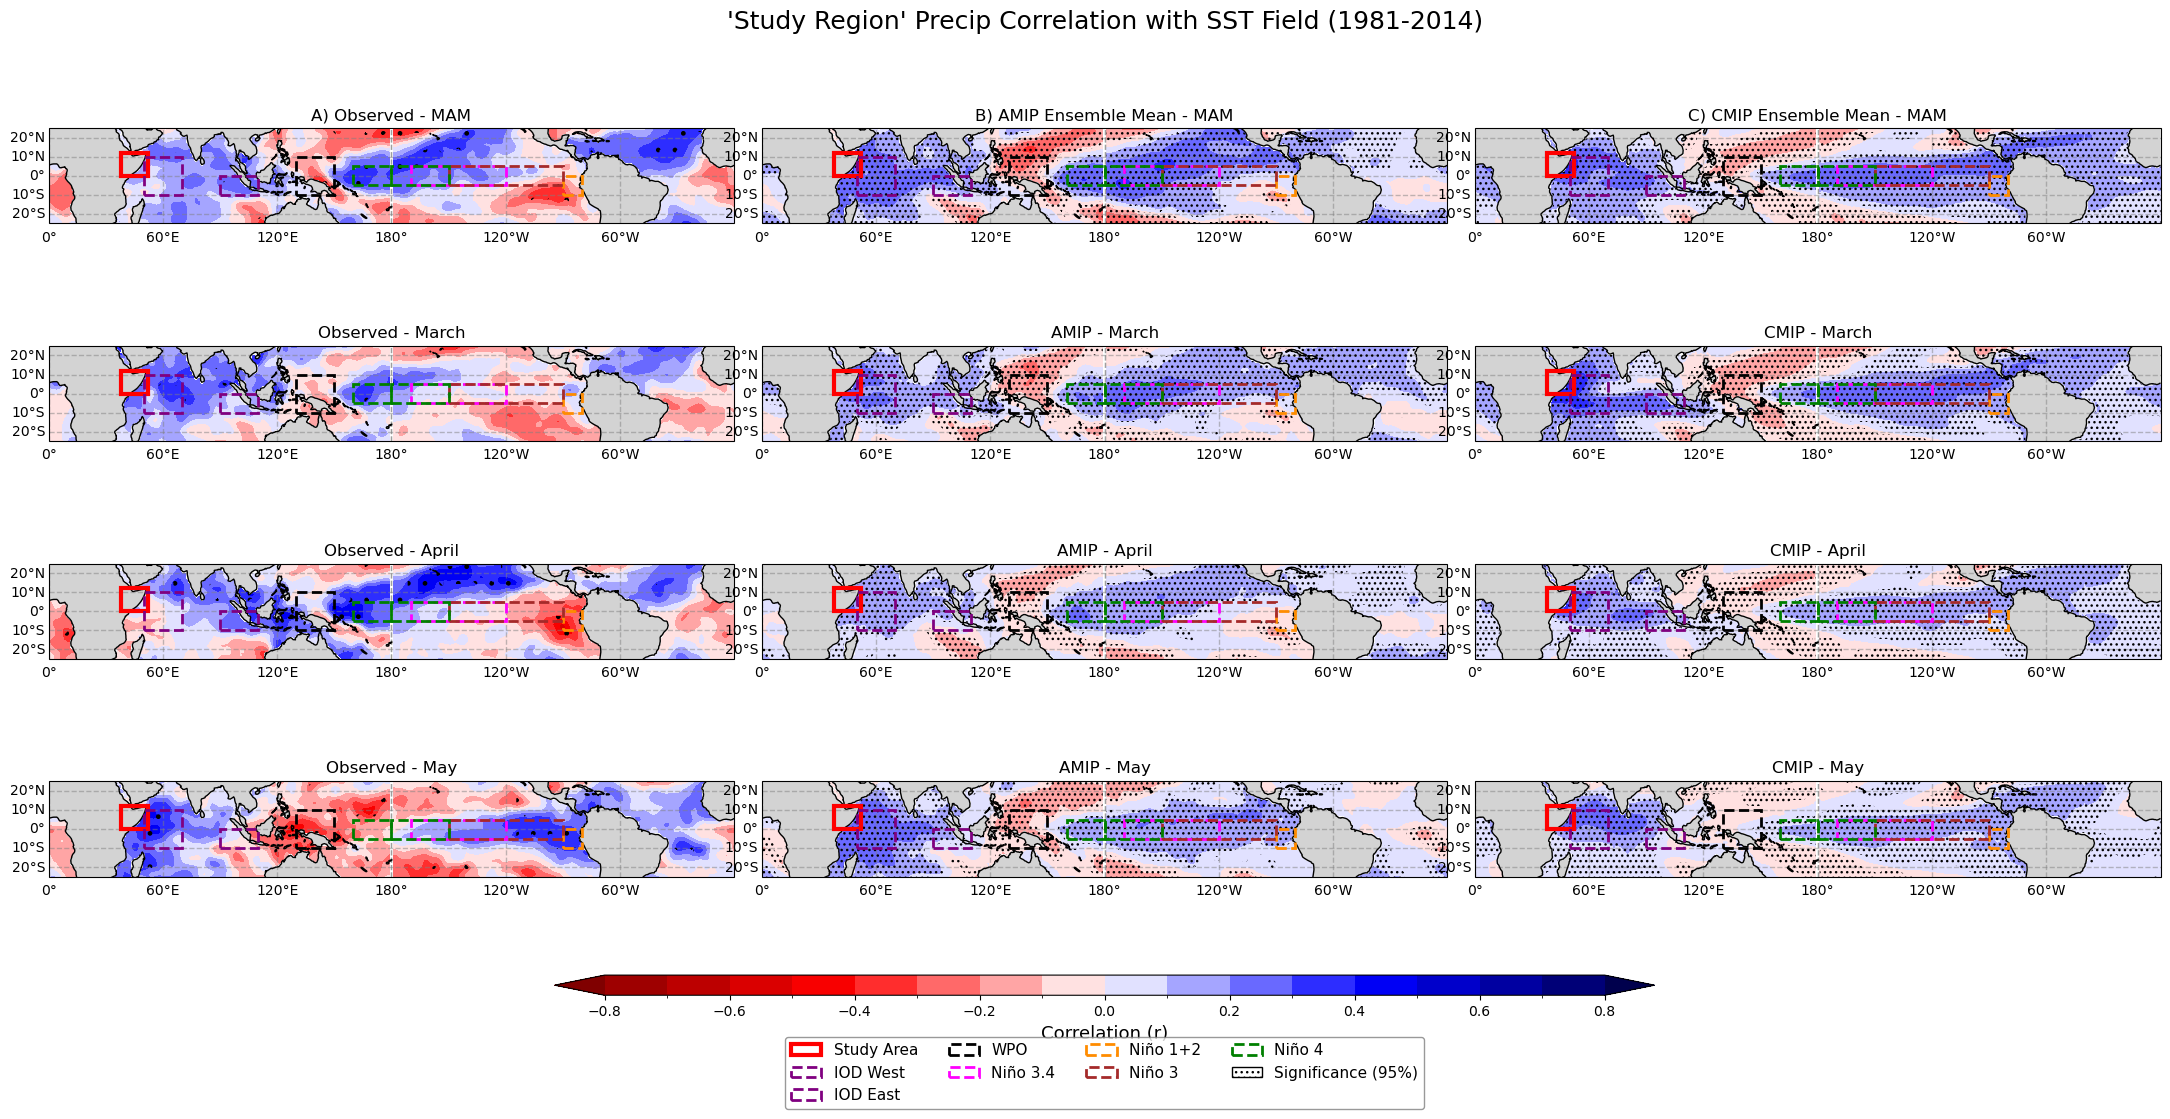

✅ Saved and displayed optimized master plot: /nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/Fig_Combined_Teleconnection_Master_tele_sst_IOD.png


In [9]:
print("--- 4. Generating Combined Teleconnection Master Plot (Layout Optimized) ---")

reference_key = "tele_sst_IOD" 
boxes_to_draw = ['study', 'wio', 'eio', 'wpo', 'nino34', 'nino12', 'nino3', 'nino4']
plot_extent = [-180, 180, -25, 25] 

num_periods = len(periods_to_process)

# 1. CRITICAL FIX: Lower the height per row from ~5 to ~2.2 inches.
# For a 7:1 map strip, 2.2 inches of height matches 24 inches of total width across 3 columns.
fig, axes = plt.subplots(
    nrows=num_periods, 
    ncols=3, 
    figsize=(22, 2.3 * num_periods + 2), # Adds a small buffer for title and legend
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)}
)

if num_periods == 1:
    axes = np.expand_dims(axes, axis=0)

# 2. Lower the main title so it sits closer to the top row
fig.suptitle(f"'Study Region' Precip Correlation with SST Field ({config.START_YEAR}-{config.END_YEAR})", fontsize=18, y=0.96)

im_global = None
obs_handles = None

for i, period in enumerate(periods_to_process):
    print(f"  -> Adding Teleconnection map for {period} (Row {i+1})...")
    
    ax_obs = axes[i, 0]
    ax_amip = axes[i, 1]
    ax_cmip = axes[i, 2]
    
    if period not in obs or reference_key not in obs[period]:
        for ax in [ax_obs, ax_amip, ax_cmip]:
            ax.text(0.5, 0.5, f'No data for {period}', ha='center', transform=ax.transAxes)
        continue

    # Panel A: Observed
    im_obs, handles = alib.create_map_plot_teleconnection(
        ax_obs, obs[period][reference_key].where(ocean_mask), 
        title=f"A) Observed - {period}" if i == 0 else f"Observed - {period}", 
        cbar_label="Correlation (r)", extent=plot_extent, 
        boxes_to_add=boxes_to_draw, add_colorbar=False
    )
    alib.add_significance(ax_obs, obs[period][f"{reference_key}_pval"], fdr_mask=obs[period][f"{reference_key}_fdr"])
    if im_obs is not None: 
        im_global = im_obs
        obs_handles = handles
    
    # Panel B: AMIP
    if period in amip and f"{reference_key}_mean" in amip[period]:
        im_amip, _ = alib.create_map_plot_teleconnection(
            ax_amip, amip[period][f"{reference_key}_mean"], 
            title=f"B) AMIP Ensemble Mean - {period}" if i == 0 else f"AMIP - {period}", 
            cbar_label="Correlation (r)", extent=plot_extent, 
            boxes_to_add=boxes_to_draw, add_colorbar=False
        )
        alib.add_ensemble_significance(ax_amip, amip[period][f"{reference_key}_sig"])
        if im_global is None and im_amip is not None: im_global = im_amip
    else:
        ax_amip.set_title(f"AMIP - {period}")
        ax_amip.text(0.5, 0.5, 'AMIP data not found', ha='center', transform=ax_amip.transAxes)

    # Panel C: CMIP
    if period in cmip and f"{reference_key}_mean" in cmip[period]:
        im_cmip, _ = alib.create_map_plot_teleconnection(
            ax_cmip, cmip[period][f"{reference_key}_mean"], 
            title=f"C) CMIP Ensemble Mean - {period}" if i == 0 else f"CMIP - {period}", 
            cbar_label="Correlation (r)", extent=plot_extent, 
            boxes_to_add=boxes_to_draw, add_colorbar=False
        )
        alib.add_ensemble_significance(ax_cmip, cmip[period][f"{reference_key}_sig"])
        if im_global is None and im_cmip is not None: im_global = im_cmip
    else:
        ax_cmip.set_title(f"CMIP - {period}")
        ax_cmip.text(0.5, 0.5, 'CMIP data not found', ha='center', transform=ax_cmip.transAxes)

# 3. CRITICAL FIX: Aggressively tighten vertical (hspace) and horizontal (wspace) margins
plt.subplots_adjust(top=0.90, bottom=0.14, left=0.02, right=0.98, hspace=0.10, wspace=0.04) 

# 4. Bring the colorbar and legend up slightly to sit snugly beneath the bottom row
if im_global is not None:
    cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.018]) # Thinner, sleeker colorbar height
    cbar = fig.colorbar(im_global, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("Correlation (r)", fontsize=13)

if obs_handles is not None:
    fig.legend(
        handles=obs_handles, loc='upper center', 
        ncol=4, fontsize=11, bbox_to_anchor=(0.5, 0.05), # 4 columns makes legend compact over 2 rows
        frameon=True, fancybox=True, shadow=False, edgecolor='gray'
    )

fig_path = fig_dir / f"Fig_Combined_Teleconnection_Master_{reference_key}.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Saved and displayed optimized master plot: {fig_path}")